### 1. Load the uploaded dataset to examine its structure and contents

**1.1 Import Libraries and Load Dataset**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


# Load the uploaded dataset to examine its structure and contents
file_path = 'heart.csv'
data = pd.read_csv(file_path)

**1.2 Provide data abstractions including dimensions, attributes, and missing values.**

In [3]:
# Data abstractions
dimensions = data.shape  # Dimensions of the dataset
attributes = data.columns.tolist()  # List of attributes
missing_values = data.isnull().sum()  # Missing values per attribute

# Create a summary dictionary
data_abstraction = {
    "Dimensions": dimensions,
    "Attributes": attributes,
    "Missing Values": missing_values
}

data_abstraction

{'Dimensions': (303, 14),
 'Attributes': ['age',
  'sex',
  'cp',
  'trtbps',
  'chol',
  'fbs',
  'restecg',
  'thalachh',
  'exng',
  'oldpeak',
  'slp',
  'caa',
  'thall',
  'output'],
 'Missing Values': age         0
 sex         0
 cp          0
 trtbps      0
 chol        0
 fbs         0
 restecg     0
 thalachh    0
 exng        0
 oldpeak     0
 slp         0
 caa         0
 thall       0
 output      0
 dtype: int64}

**1.3 Clean the data (remove or replace missing values, standardize features).**

In [4]:
# Step 1: Handle missing values (if any)
# As there are no missing values in this dataset, no removal or replacement is necessary.

# Step 2: Standardize numerical features
# Identify numerical columns
numerical_columns = ['age', 'trtbps', 'chol', 'thalachh', 'oldpeak']

# Initialize the StandardScaler
scaler = StandardScaler()

# Standardize numerical columns
data[numerical_columns] = scaler.fit_transform(data[numerical_columns])

# Display the cleaned dataset's first few rows
cleaned_data_preview = data.head()
cleaned_data_preview

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,0.952197,1,3,0.763956,-0.256334,1,0,0.015443,0,1.087338,0,0,1,1
1,-1.915313,1,2,-0.092738,0.072199,0,1,1.633471,0,2.122573,0,0,2,1
2,-1.474158,0,1,-0.092738,-0.816773,0,0,0.977514,0,0.310912,2,0,2,1
3,0.180175,1,1,-0.663867,-0.198357,0,1,1.239897,0,-0.206705,2,0,2,1
4,0.290464,0,0,-0.663867,2.082050,0,1,0.583939,1,-0.379244,2,0,2,1


**1.4 Split the data into training and testing sections.**

In [5]:
# Define features (X) and target (y)
X = data.drop(columns=['output'])  # Features
y = data['output']  # Target

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Display the shapes of the splits
split_shapes = {
    "X_train Shape": X_train.shape,
    "X_test Shape": X_test.shape,
    "y_train Shape": y_train.shape,
    "y_test Shape": y_test.shape
}

split_shapes

{'X_train Shape': (242, 13),
 'X_test Shape': (61, 13),
 'y_train Shape': (242,),
 'y_test Shape': (61,)}

### 2. Implementing gradient descent techniques

**2.1 Create regression models using three gradient descent methods (Batch Gradient Descent, Stochastic Gradient Descent, and Mini-Batch Gradient Descent).**

In [6]:
class GradientDescentRegressor:
    def __init__(self, learning_rate=0.01, iterations=1000, method='batch', batch_size=32):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.method = method
        self.batch_size = batch_size
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        m, n = X.shape
        self.weights = np.zeros(n)
        self.bias = 0

        for i in range(self.iterations):
            if self.method == 'batch':
                dw, db = self._compute_gradients(X, y, m)
            elif self.method == 'stochastic':
                idx = np.random.randint(0, m)
                dw, db = self._compute_gradients(X[idx:idx+1], y[idx:idx+1], 1)
            elif self.method == 'mini-batch':
                idx = np.random.choice(m, self.batch_size, replace=False)
                dw, db = self._compute_gradients(X[idx], y[idx], len(idx))
            else:
                raise ValueError("Invalid method. Choose 'batch', 'stochastic', or 'mini-batch'.")

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

    def _compute_gradients(self, X, y, m):
        y_pred = np.dot(X, self.weights) + self.bias
        dw = (1 / m) * np.dot(X.T, (y_pred - y))
        db = (1 / m) * np.sum(y_pred - y)
        return dw, db


# Convert training and testing data to numpy arrays
X_train_np = X_train.to_numpy()
y_train_np = y_train.to_numpy()
X_test_np = X_test.to_numpy()
y_test_np = y_test.to_numpy()

# Train models using each gradient descent method
methods = ['batch', 'stochastic', 'mini-batch']
results = {}

for method in methods:
    model = GradientDescentRegressor(learning_rate=0.01, iterations=1000, method=method, batch_size=32)
    model.fit(X_train_np, y_train_np)
    predictions = model.predict(X_test_np)
    results[method] = predictions

results

{'batch': array([ 0.04652779,  0.28421262, -0.02477841,  0.58890937,  0.67950319,
         0.3174308 ,  0.44822951, -0.04873164,  1.04391744,  0.77434154,
         0.35543379,  0.36764986,  0.16584669,  0.85290462,  1.0435281 ,
         0.92062097,  0.95634197,  0.42082295,  0.77275242,  0.5662124 ,
         0.67563992,  0.12209729,  0.83288358,  0.61861598,  0.51168747,
        -0.1301772 ,  0.42702461,  0.40766494,  0.1440756 ,  0.50407008,
         0.08223142,  0.56819703,  0.28817031,  0.35228327,  0.03849318,
         0.6455333 ,  0.46711407,  0.91318533,  0.89817514,  0.5030834 ,
         0.36663129,  1.00693327,  0.97621342,  0.76132962,  0.38788816,
         0.23337539,  0.79161248,  0.62886447,  0.39037959,  1.00330393,
         0.66654168,  0.88661891,  0.86770954, -0.05569169,  0.72000703,
         1.04170701,  1.10917374,  0.56875376,  0.08939639,  0.27455192,
         0.79268248]),
 'stochastic': array([ 0.15548561,  0.4850318 ,  0.03051063,  0.5317117 ,  0.78171068,
     

**2.2 Train different algorithms and adjust hyperparameters (such as learning rate and batch size).**

In [7]:
# Define a function to train models with different hyperparameters and evaluate their performance
def train_and_evaluate(method, learning_rates, batch_sizes):
    results = []

    for lr in learning_rates:
        for batch_size in batch_sizes:
            model = GradientDescentRegressor(learning_rate=lr, iterations=1000, method=method, batch_size=batch_size)
            model.fit(X_train_np, y_train_np)
            predictions = model.predict(X_test_np)
            mse = mean_squared_error(y_test_np, predictions)

            results.append({
                'Method': method,
                'Learning Rate': lr,
                'Batch Size': batch_size,
                'MSE': mse
            })

    return results

# Define hyperparameter ranges
learning_rates = [0.001, 0.01, 0.1]
batch_sizes = [16, 32, 64]

# Train models for each method
batch_results = train_and_evaluate('batch', learning_rates, [len(X_train)])  # Batch uses full data
stochastic_results = train_and_evaluate('stochastic', learning_rates, [1])  # Stochastic uses batch size of 1
mini_batch_results = train_and_evaluate('mini-batch', learning_rates, batch_sizes)

# Combine results
all_results = pd.DataFrame(batch_results + stochastic_results + mini_batch_results)

# Display the results
all_results


,Method,Learning Rate,Batch Size,MSE
0,batch,0.001,242,0.178469
1,batch,0.010,242,0.160963
2,batch,0.100,242,0.144345
3,stochastic,0.001,1,0.184914
4,stochastic,0.010,1,0.157658
5,stochastic,0.100,1,425243.710099
6,mini-batch,0.001,16,0.177763
7,mini-batch,0.001,32,0.179374
8,mini-batch,0.001,64,0.178127
9,mini-batch,0.010,16,0.161785


### 3. Compression

**3.1 Visualize the training and testing error of each model over the iterations.**

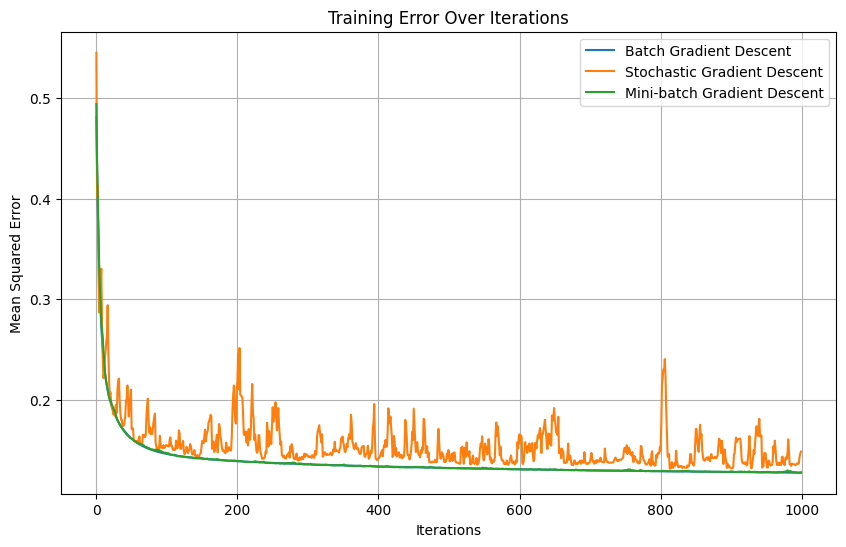

In [54]:
# Define a modified GradientDescentRegressor to track error over iterations
class GradientDescentRegressorWithTracking(GradientDescentRegressor):
    def fit(self, X, y):
        m, n = X.shape
        self.weights = np.zeros(n)
        self.bias = 0
        self.training_errors = []

        for i in range(self.iterations):
            if self.method == 'batch':
                dw, db = self._compute_gradients(X, y, m)
            elif self.method == 'stochastic':
                idx = np.random.randint(0, m)
                dw, db = self._compute_gradients(X[idx:idx+1], y[idx:idx+1], 1)
            elif self.method == 'mini-batch':
                idx = np.random.choice(m, self.batch_size, replace=False)
                dw, db = self._compute_gradients(X[idx], y[idx], len(idx))
            else:
                raise ValueError("Invalid method. Choose 'batch', 'stochastic', or 'mini-batch'.")

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Calculate and store the training error
            y_pred = np.dot(X, self.weights) + self.bias
            mse = mean_squared_error(y, y_pred)
            self.training_errors.append(mse)

# Train models with tracking for visualization
methods = ['batch', 'stochastic', 'mini-batch']
tracked_results = {}

for method in methods:
    model = GradientDescentRegressorWithTracking(learning_rate=0.01, iterations=1000, method=method, batch_size=32)
    model.fit(X_train_np, y_train_np)
    tracked_results[method] = model.training_errors

# Visualize training error over iterations
plt.figure(figsize=(10, 6))
for method, errors in tracked_results.items():
    plt.plot(errors, label=f"{method.capitalize()} Gradient Descent")

plt.title("Training Error Over Iterations")
plt.xlabel("Iterations")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid()
plt.show()


**3.2 Provide graphs to compare the performance of gradient descent techniques.**

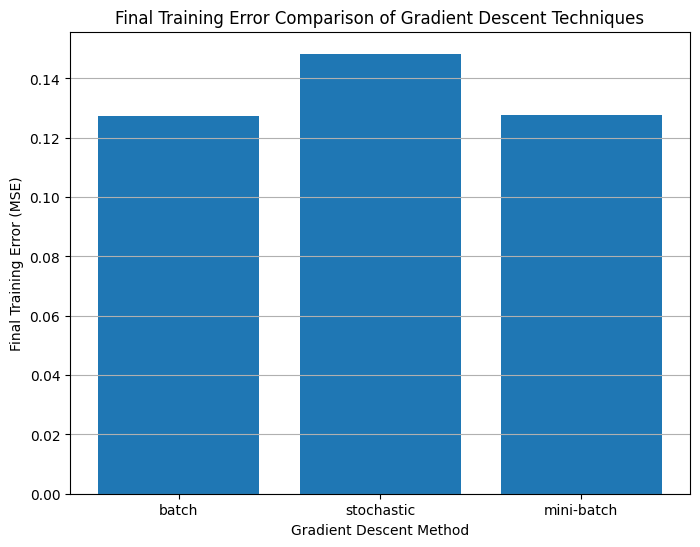

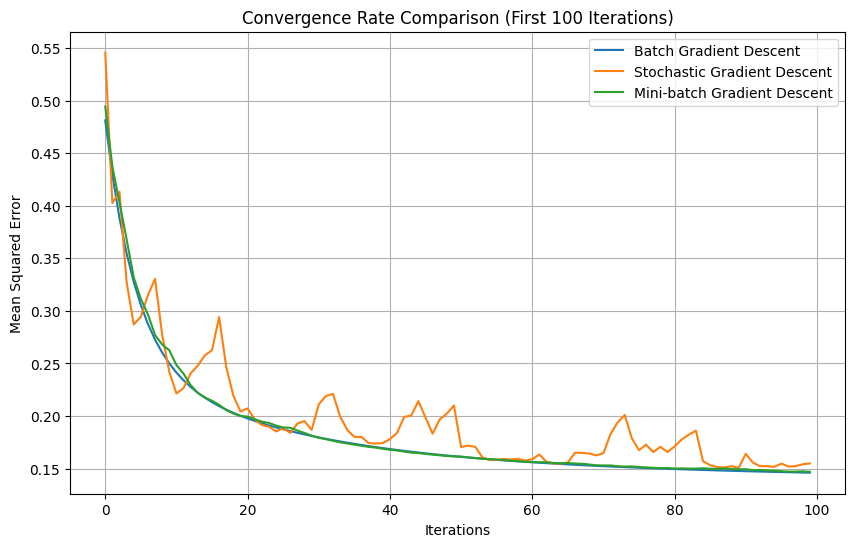

In [55]:
# Prepare data for comparison: Final training errors for each method
final_training_errors = {method: errors[-1] for method, errors in tracked_results.items()}

# Performance comparison graph
plt.figure(figsize=(8, 6))
plt.bar(final_training_errors.keys(), final_training_errors.values())
plt.title("Final Training Error Comparison of Gradient Descent Techniques")
plt.xlabel("Gradient Descent Method")
plt.ylabel("Final Training Error (MSE)")
plt.grid(axis="y")
plt.show()

# Visualize the convergence rates (subset of iterations for clarity)
plt.figure(figsize=(10, 6))
for method, errors in tracked_results.items():
    plt.plot(errors[:100], label=f"{method.capitalize()} Gradient Descent")
plt.title("Convergence Rate Comparison (First 100 Iterations)")
plt.xlabel("Iterations")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid()
plt.show()